# Project 2: Medical Route Optimization

This notebook demonstrates the Genetic Algorithm solution for the Vehicle Routing Problem (VRP) in a medical delivery context.

In [38]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
import random
from src.models.location import Location
from src.models.vehicle import Vehicle
from src.algorithms.genetic_optimizer import GeneticOptimizer
from src.utils.plotter import Plotter
from src.llm.report_generator import ReportGenerator
from src.utils.data_loader import DataLoader

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
# 1. Define Problem Data
depot = Location(0, 50, 50, "Central Depot", type='depot')

NUM_LOCATIONS = 60

locations = DataLoader.load_data(limit=NUM_LOCATIONS, data_dir='../data')

# Create Fleet
# Estimate required capacity
deliveries = [l for l in locations if getattr(l, 'type', 'delivery') == 'delivery']
total_demand = sum(l.demand for l in deliveries)
num_vehicles = 6

fleet = []
total_capacity = 0
total_distance = 0
for i in range(num_vehicles):
    capacity = random.randint(3, 6)
    total_capacity += capacity
    max_distance = random.randint(100, 200)
    total_distance += max_distance
    fleet.append(Vehicle(id=i+1, capacity=capacity, max_distance=max_distance))

print(f"Loaded {NUM_LOCATIONS} locations from dataset and {len(locations) - NUM_LOCATIONS} gas stations.")
print(f"Created Fleet of {len(fleet)} vehicles with total load capacity of {total_capacity} and total autonomy distance of {total_distance}")
print("Fleet: ")
for vehicle in fleet:
    print(f"Vehicle {vehicle.id} has a capacity of {vehicle.capacity} and a max distance of {vehicle.max_distance}")

Loaded 60 locations from dataset and 10 gas stations.
Created Fleet of 6 vehicles with total load capacity of 21 and total autonomy distance of 1033
Fleet: 
Vehicle 1 has a capacity of 4 and a max distance of 143
Vehicle 2 has a capacity of 5 and a max distance of 199
Vehicle 3 has a capacity of 3 and a max distance of 176
Vehicle 4 has a capacity of 3 and a max distance of 178
Vehicle 5 has a capacity of 3 and a max distance of 163
Vehicle 6 has a capacity of 3 and a max distance of 174


In [40]:
# 2. Run Genetic Algorithm
# Adjust generations/pop_size based on problem size if needed
locations_times_vehicles = NUM_LOCATIONS * num_vehicles
generations = locations_times_vehicles * 4 
population_size = 60
early_stopping_rounds = 50


optimizer = GeneticOptimizer(locations, depot, fleet, generations=generations, population_size=population_size, early_stopping_rounds=early_stopping_rounds, priority_weight=0.1)
best_routes, best_dist, fitness_history = optimizer.run()

print(f"Best Total Distance: {best_dist:.2f}")

Stopping early at generation 328 due to no improvement for 50 rounds.
Best Total Distance: 1861.70


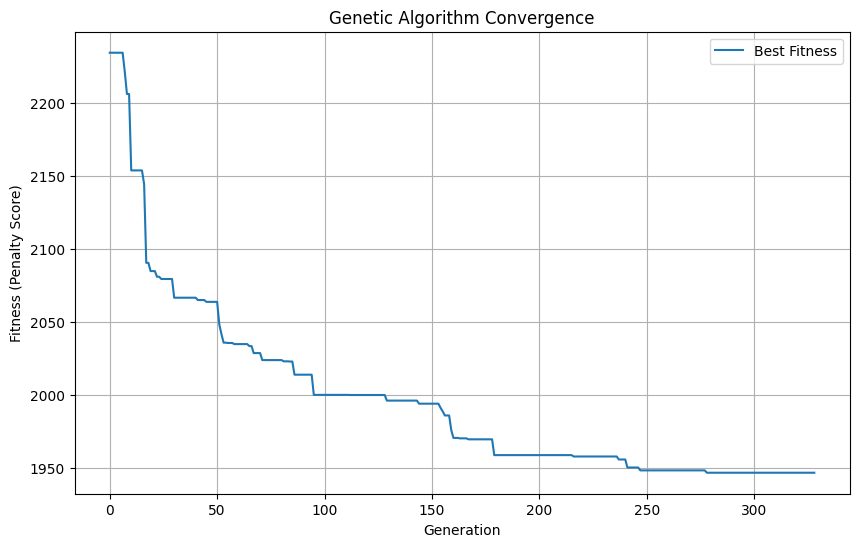

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(fitness_history, label='Best Fitness')
plt.title('Genetic Algorithm Convergence')
plt.xlabel('Generation')
plt.ylabel('Fitness (Penalty Score)')
plt.grid(True)
plt.legend()
plt.show()

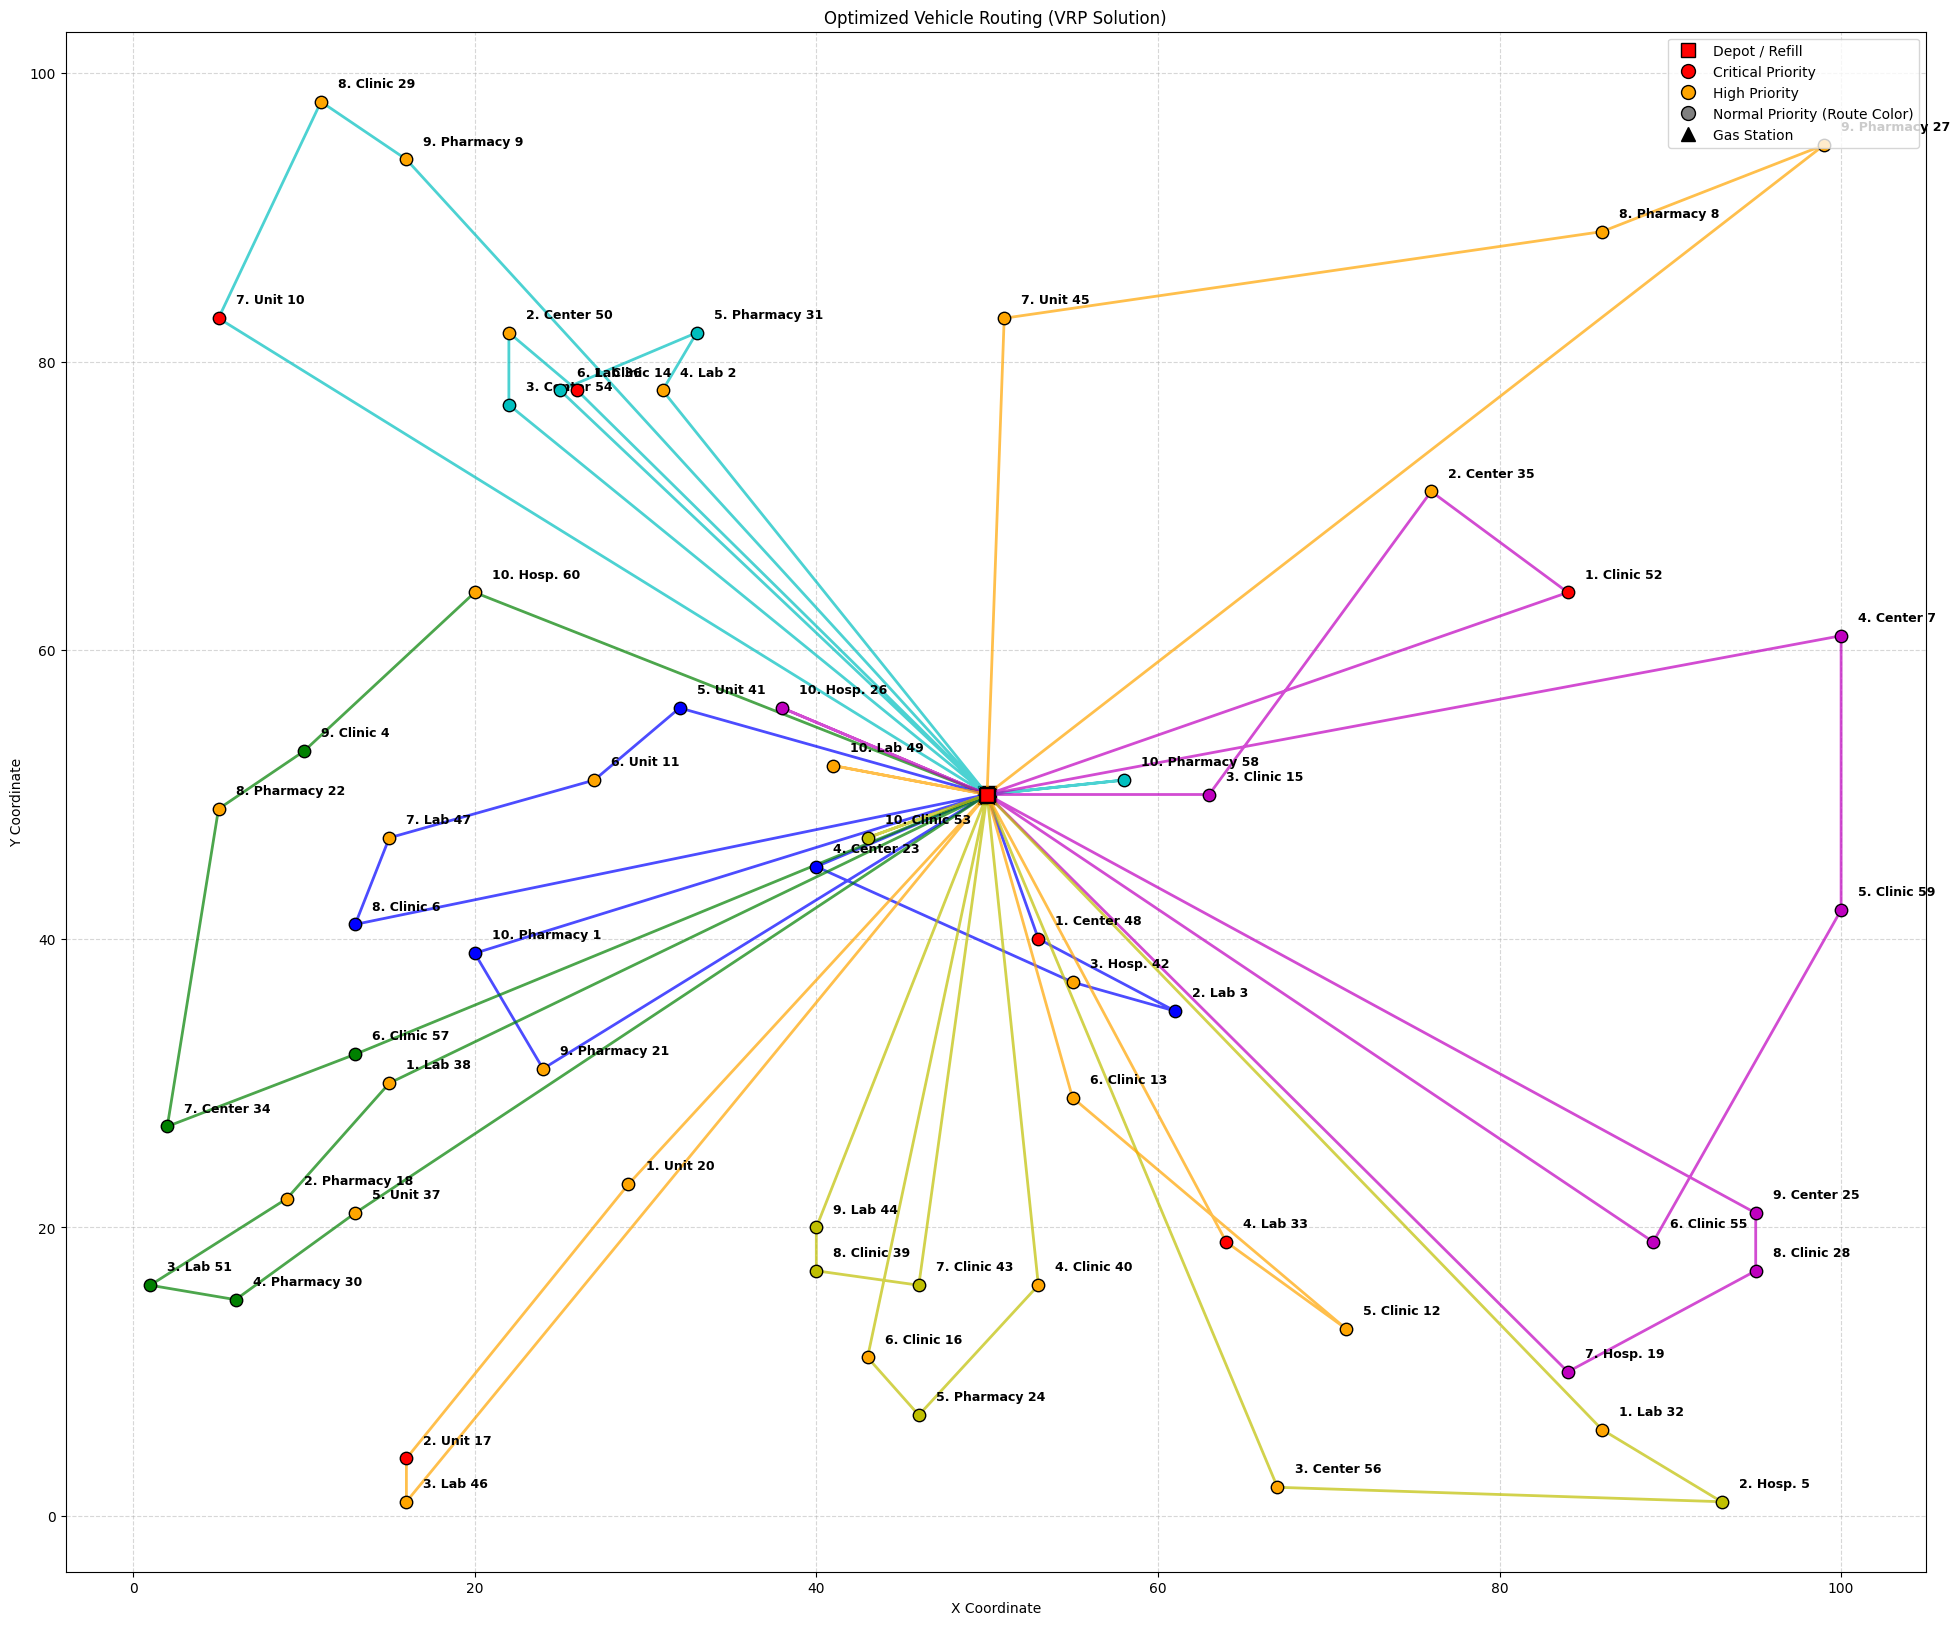

In [42]:
# 3. Visualize Solution
Plotter.plot_solution(best_routes, depot)

In [43]:
# 4. Generate LLM Report
llm = ReportGenerator() # Will use mock if no API key

print("Generating Instructions for Drivers...\n")

max_reports = 3

for i, route in enumerate(best_routes[:max_reports]):
    print(llm.generate_driver_instructions(i, route))
    print("\n" + "="*40 + "\n")

if len(best_routes) > max_reports:
    print(f"... and {len(best_routes) - max_reports} more routes.")

Using cached LLM model.
Generating Instructions for Drivers...

Hey there,

Good morning! 🌞

Here's your day:

- Center 48 (High Priority)
- Lab 3 (Normal Priority)
- Hosp. 42 (Immediate Priority)
- Center 23 (Normal Priority)

Then it's all this:

- Central Depot: Unit 41 (Normal Priority)
- Central Depot: Unit 11 (Immediate Priority)
- Lab 47 (Immediate Priority)
- Clinic 6 (Normal Priority)

Last but not least, stay safe out there! 🚗👩‍(driver)👨‍(driver)


Hey there,

Good morning! Got a busy day ahead.

- Lab 38 - Priority: Immediate
- Pharmacy 18 - Priority: Immediate
- Lab 51 - Priority: Normal
- Pharmacy 30 - Priority: Normal
- Unit 37 - Priority: Immediate

Then it's off to Central Depot:

- Clinic 57 - Priority: Normal
- Center 34 - Priority: Normal
- Pharmacy 22 - Priority: Immediate
- Clinic 4 - Priority: Normal
- Hosp. 60 - Priority: Immediate

Central Depot again!

Stay safe out there!

Talk soon!


Hey Driver!

Good day! 

Start at Clinic 14 (High priority), then rush to C